In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

DOCKING_RESULTS = {}
# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
    # Get scores
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
    # Save results
    DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# Sort pockets by median
pockets = sorted(DOCKING_RESULTS)
medians = [np.median(list(DOCKING_RESULTS[p].values())) for p in pockets]
ind = np.argsort(medians)
pockets = np.array(pockets)[ind]

100%|██████████| 276/276 [12:41<00:00,  2.76s/it]


In [82]:
# Load labels
root = '.'
PATH_TO_PROBS = os.path.join(root, "..", "processed", "unidock_docking", "inferences_top100k")
labels = np.array(pickle.load(open(os.path.join(PATH_TO_PROBS, "success_mols.pkl"), "rb")))

In [83]:
pocket_to_probs = {}
TOPs = [10, 100, 1000, 10000, 100000]
cmap = plt.cm.viridis
colors_to_use = cmap(np.linspace(0, 1, len(TOPs)))

# For each pocket
for c, pocket in tqdm(enumerate(pockets)):

    pocket_to_probs[pocket] = {}

    # If probs already calculated
    if f"{pocket}_bin_01.npz" in os.listdir(PATH_TO_PROBS):

        # Load probs
        probs = np.load(os.path.join(PATH_TO_PROBS, f"{pocket}_bin_01.npz"))["arr_0"]
        probs = np.sort(probs)[::-1]
        for TOP in TOPs:
            pocket_to_probs[pocket][TOP] = probs[TOP]
            
    else:
        for TOP in TOPs:
            pocket_to_probs[pocket][TOP] = 0

276it [01:15,  3.63it/s]


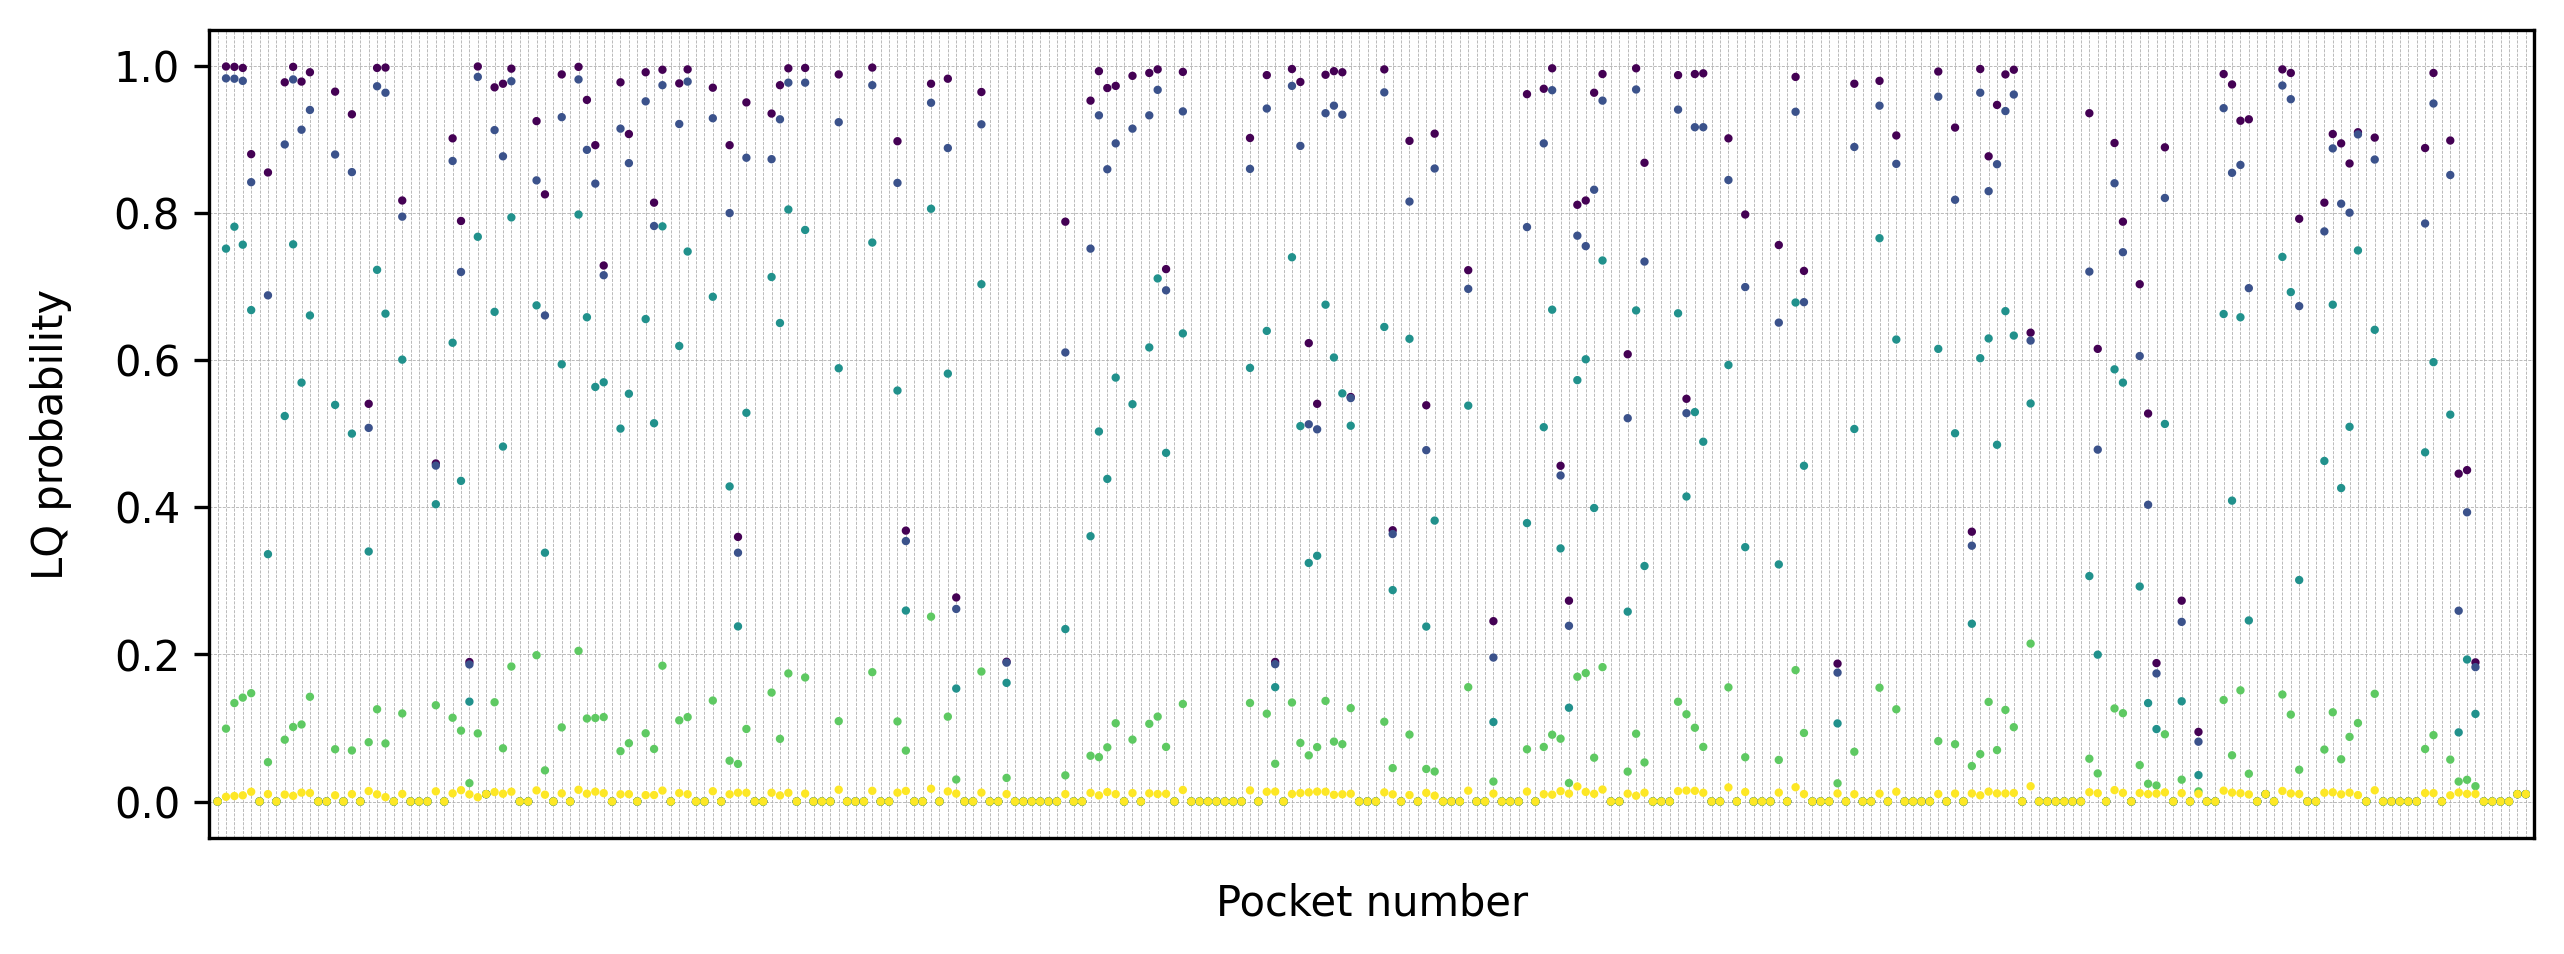

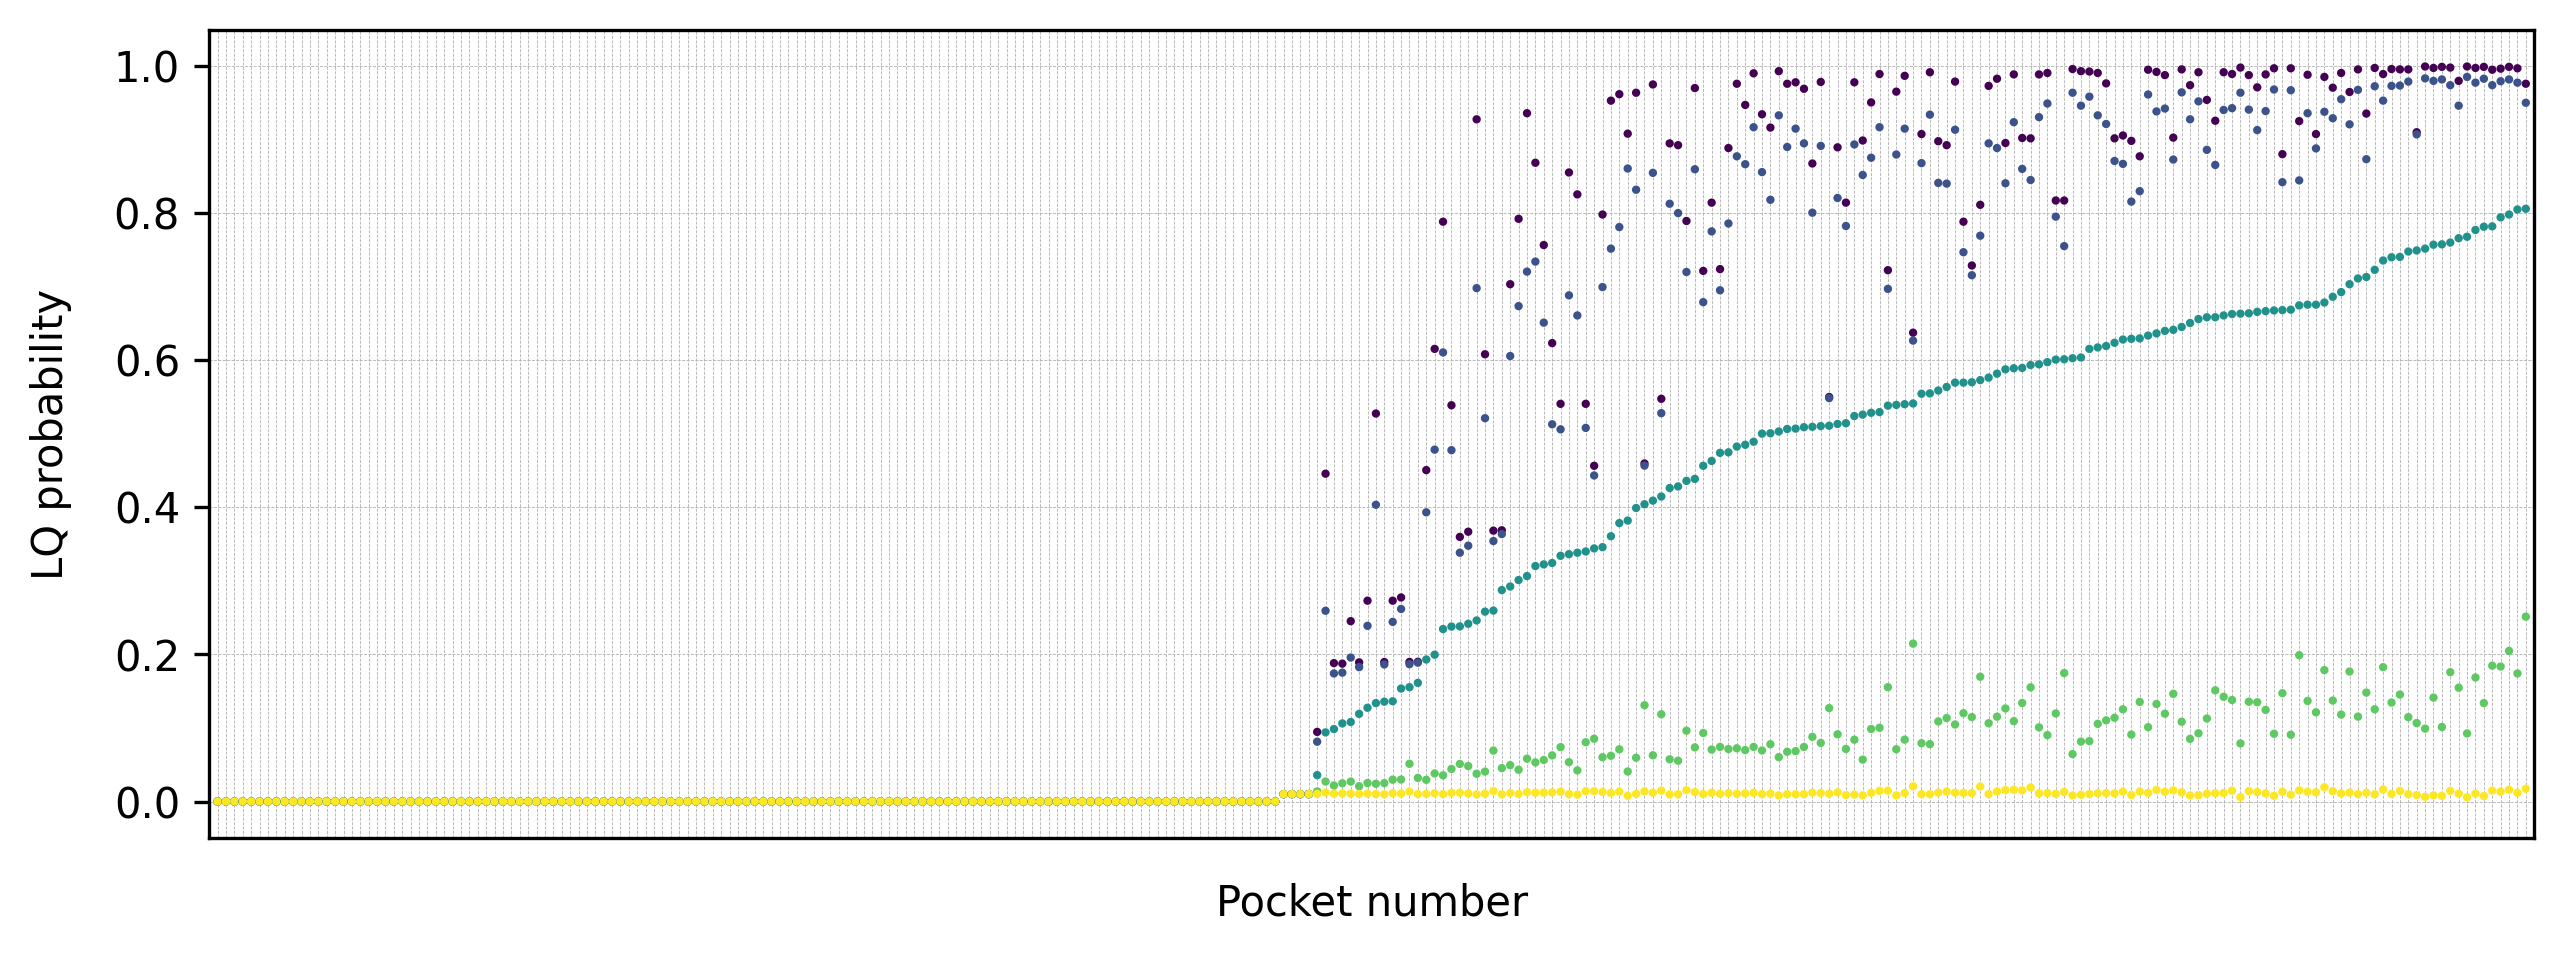

In [88]:
x, y, colors = [], [], []
for c, pocket in enumerate(pockets):
    for color, TOP in zip(colors_to_use, TOPs):
        x.append(c)
        y.append(pocket_to_probs[pocket][TOP])
        colors.append(color)
 
fig, ax = plt.subplots(figsize=(10, 3.5))
plt.scatter(x, y, c=colors, zorder=2, s=1)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("LQ probability", labelpad=10)
plt.xlim([-1, 276])
plt.show()


x, y, colors = [], [], []
pockets_sorted = sorted(pockets, key = lambda x: pocket_to_probs[x][1000])
for c, pocket in enumerate(pockets_sorted):
    for color, TOP in zip(colors_to_use, TOPs):
        x.append(c)
        y.append(pocket_to_probs[pocket][TOP])
        colors.append(color)
 
fig, ax = plt.subplots(figsize=(10, 3.5))
plt.scatter(x, y, c=colors, zorder=2, s=1)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("LQ probability", labelpad=10)
plt.xlim([-1, 276])
plt.show()

In [73]:
pocket

np.str_('swissmodel_P9WFU3_model_0_pocket_1')

In [74]:
pocket_to_probs[pocket]

{}